# Astronomical Computing Assignment 2

Julian Berg, u8276317

### 1) git in Practice

We create a git repository for this assignment. It can be found [here](https://github.com/JulianLBerg/Astrocomp_Assignment2).

### 2) Bright Stars Around M67 with ADQL

1. From the Gaia archive, we want to download the stars of the open cluster Messier 67. Therefore, we use the following ADQL query on the Gaia archive website.

```ADQL
SELECT gaia.source_id, gaia.ra, gaia.dec, gaia.phot_g_mean_mag, gaia.parallax, gaia.pmra, gaia.pmdec, tmass.designation, tmass.ra AS tmass_ra, tmass.dec AS tmass_dec, xmatch.angular_distance
FROM gaiadr3.gaia_source AS gaia
JOIN gaiadr3.tmass_psc_xsc_best_neighbour AS xmatch USING (source_id)
JOIN gaiadr3.tmass_psc_xsc_join AS xjoin USING (clean_tmass_psc_xsc_oid)
JOIN gaiadr1.tmass_original_valid AS tmass ON xjoin.original_psc_source_id = tmass.designation
WHERE 1 = CONTAINS(POINT('ICRS', gaia.ra, gaia.dec), CIRCLE('ICRS', 132.825, 11.8, 1.0))
AND gaia.phot_g_mean_mag < 14
```

This returns 1018 stars.

2. Now, we want to identify the stars with a bad 2MASS photometry (ph_qual is not 'AAA') or with non-positive values of Gaia parallax. We do this by adding the line 

```ADQL
AND (tmass.ph_qual != 'AAA' OR parallax <= 0)
```

We identify 23 stars, which do fullfill wither of these conditions. For the next query, we want to cut these by 

```
AND tmass.ph_qual = 'AAA'
AND parallax > 0
```

We are left with 988 stars. Apparently, some of the stars fulfill both criteria.


3. Now, we want to create and save a two-panel figure showing the Gaia BP-RP versus absolute G magnitude and the 2MASS J-Ks versus apparent H magnitude. Therefore, we download the data and move it into the data folder. In the following steps, we explain the code.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table

In [ ]:
# Import Gaia and 2MASS data
data = Table.read('../data/Gaia_data')

In [ ]:
# Define properties
bp_rp = data['bp_rp']
g_mag = data['phot_g_mean_mag']
j_m = data['j_m']
ks_m = data['ks_m']
h_m = data['h_m']
parallax = data['parallax']

In [ ]:
# Compute distance from parallax and absolute G magnitude from apparent G magnitude and distance
distance = 1000 / parallax
G_mag = g_mag - 5 * np.log10(distance) + 5

# Compute J - K
J_K = j_m - ks_m

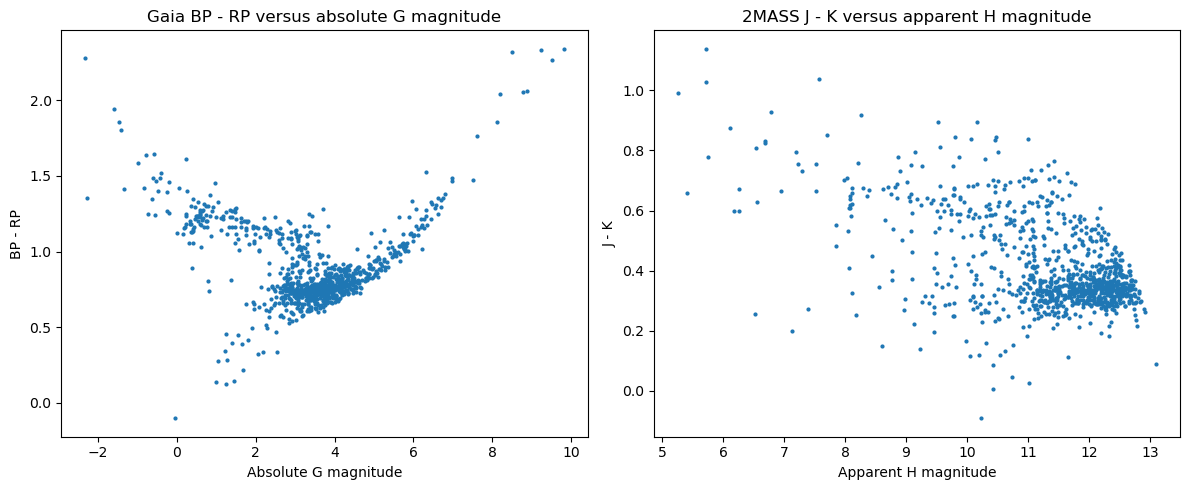

In [ ]:
# Create two-panel figure with the two given plots
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(G_mag, bp_rp, s=4)
ax[0].set_xlabel('Absolute G magnitude')
ax[0].set_ylabel('BP - RP')
ax[0].set_title('Gaia BP - RP versus absolute G magnitude')

ax[1].scatter(h_m, J_K, s=4)
ax[1].set_xlabel('Apparent H magnitude')
ax[1].set_ylabel('J - K')
ax[1].set_title('2MASS J - K versus apparent H magnitude')

plt.tight_layout()
plt.savefig('../figures/M67_diagrams.png')  # Save figure in the folder figures
plt.show()


4. Given the different criteria for the selection of stars, we had a final number of 988 stars. The HERMES spectrograph has two field plates with 392 science fibres each. Since 988 / 392 ≈ 2.52, three separate fibre configurations would be needed to observe all 988 stars. Two configurations would fully use all 392 fibres each. The third configuration would only need 988 − 784 = 204 stars, leaving 392 − 204 = 188 fibres (about 48% of the plate) unused. Given that nearly half of the fibres in the final configuration would go unused, this field would not make efficient use of 2dF/HERMES's fibre capacity, and I would not recommend it.